Problem statement: Analysis and Visualization of Stock Market Data 
Tasks to Perform: 
1. Import the "Stock_Prices.csv" dataset. 
2. Explore the dataset to understand its structure and content. 
3. Ensure that the date column is in the appropriate format (e.g., datetime) for time series 
analysis. 
4. Plot line charts or time series plots to visualize the historical stock price trends over 
time. 
5. Calculate and plot moving averages or rolling averages to identify the underlying 
trends and smooth out noise. 
6. Perform seasonality analysis to identify periodic patterns in the stock prices, such as 
weekly, monthly, or yearly fluctuations. 
7. Analyze and plot the correlation between the stock prices and other variables, such as 
trading volume or market indices. 
8. Use autoregressive integrated moving average (ARIMA) models or exponential 
smoothing models to forecast future stock prices.

In [3]:
import sys
!{sys.executable} -m pip install statsmodels


[notice] A new release of pip is available: 25.1 -> 25.3
[notice] To update, run: C:\Users\akshi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

In [5]:
stock_prices = pd.read_csv('stock_prices.csv')
stock_prices.head()

,Date,A,AA,AAPL,ABBV,ABC,ABT,ACN,ADBE,ADI,...,XEL,XL,XLNX,XOM,XRAY,XRX,XYL,YUM,ZION,ZNGA
0,2003-07-31,13.790836,53.019848,1.019303,NaN,12.739487,9.022574,15.108545,16.333433,26.962475,...,7.946304,53.450195,19.403030,24.283438,20.140688,23.011992,NaN,8.275629,46.391441,NaN
1,2003-08-01,13.676599,51.759747,1.002379,NaN,12.579965,8.859362,15.816516,16.268559,28.070812,...,7.858501,50.491951,19.898077,24.112812,19.770533,22.692390,NaN,8.272863,46.557457,NaN
2,2003-08-04,13.682946,52.256149,1.025589,NaN,12.398233,8.850165,15.660917,16.523066,28.227112,...,7.803621,51.500431,19.838972,24.303909,19.728891,21.605703,NaN,8.239684,46.673660,NaN
3,2003-08-05,13.219654,51.206055,0.985455,NaN,12.111500,8.700747,15.147444,16.183720,27.132978,...,7.699356,51.856777,19.225708,24.126451,19.405010,21.605703,NaN,8.167795,46.325050,NaN
4,2003-08-06,13.060995,50.783653,0.949190,NaN,11.752071,8.873152,14.937387,15.749559,27.175615,...,7.748745,52.643398,19.151808,24.399456,19.423517,21.818781,NaN,8.037839,46.648762,NaN


In [6]:
print("Number of Rows:",stock_prices.shape[0])
print("Number of Columns:",stock_prices.shape[1])


Number of Rows: 2876
Number of Columns: 480


In [7]:
stock_prices.dtypes

Date     object
A       float64
AA      float64
AAPL    float64
ABBV    float64
         ...   
XRX     float64
XYL     float64
YUM     float64
ZION    float64
ZNGA    float64
Length: 480, dtype: object

In [8]:
stock_prices.columns

Index(['Date', 'A', 'AA', 'AAPL', 'ABBV', 'ABC', 'ABT', 'ACN', 'ADBE', 'ADI',
       ...
       'XEL', 'XL', 'XLNX', 'XOM', 'XRAY', 'XRX', 'XYL', 'YUM', 'ZION',
       'ZNGA'],
      dtype='object', length=480)

In [9]:
stock_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2876 entries, 0 to 2875
Columns: 480 entries, Date to ZNGA
dtypes: float64(479), object(1)
memory usage: 10.5+ MB


In [10]:
stock_prices.isnull().sum()

Date       0
A          0
AA         0
AAPL       0
ABBV    2372
        ... 
XRX        0
XYL     2067
YUM        0
ZION       0
ZNGA    2112
Length: 480, dtype: int64

In [11]:
# Step 3: Ensure 'Date' column is datetime type
stock_prices['Date'] = pd.to_datetime(stock_prices['Date'])
stock_prices.set_index('Date', inplace=True)  # Set Date as index for time series

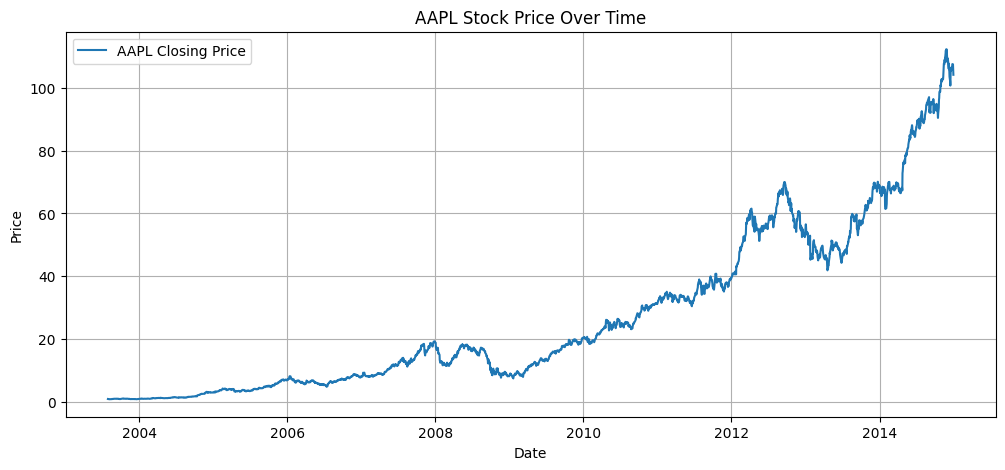

In [12]:
# Step 4: Plot historical stock price trend
plt.figure(figsize=(12,5))
plt.plot(stock_prices['AAPL'], label='AAPL Closing Price')
plt.title('AAPL Stock Price Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

In [13]:
# Step 5: Calculate and plot moving averages
stock_prices['AAPL_MA_20'] = stock_prices['AAPL'].rolling(window=20).mean()  # 20-day moving average
stock_prices['AAPL_MA_50'] = stock_prices['AAPL'].rolling(window=50).mean()  # 50-day moving average

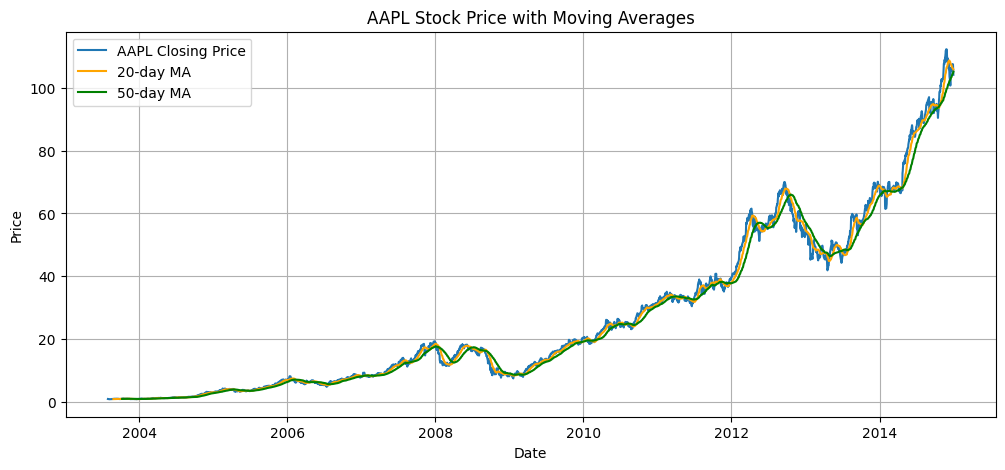

In [14]:
plt.figure(figsize=(12,5))
plt.plot(stock_prices['AAPL'], label='AAPL Closing Price')
plt.plot(stock_prices['AAPL_MA_20'], label='20-day MA', color='orange')
plt.plot(stock_prices['AAPL_MA_50'], label='50-day MA', color='green')
plt.title('AAPL Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid()
plt.show()

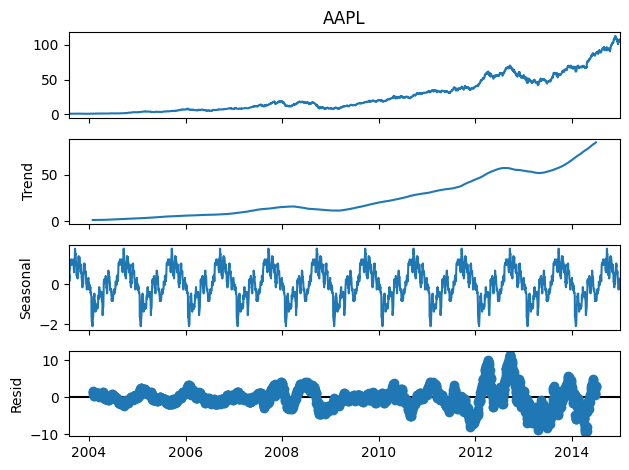

In [15]:
# Step 6: Seasonality analysis using decomposition
decomposition = seasonal_decompose(stock_prices['AAPL'], model='additive', period=252)  # approx 1 trading year
decomposition.plot()
plt.show()